In [3]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Konfigurasi Jalur Folder
folder_asal = r'D:\FILE SELA\SEMESTER 6\ML 1\PREPROSESING\Machine-Learning-1\dataset_mentah'
folder_tujuan = r'D:\FILE SELA\SEMESTER 6\ML 1\PREPROSESING\Machine-Learning-1\dataset fix'

if not os.path.exists(folder_tujuan):
    os.makedirs(folder_tujuan)

In [4]:
print("Sedang memproses gambar...")
count = 0
for nama_file in os.listdir(folder_asal):
    if nama_file.endswith(('.jpg', '.jpeg', '.png')):
        path_file = os.path.join(folder_asal, nama_file)
        img = cv2.imread(path_file)

        if img is not None:
            # Resize ke standar MobileNetV2
            img_resized = cv2.resize(img, (224, 224), interpolation=cv2.INTER_LINEAR)
            
            path_simpan = os.path.join(folder_tujuan, nama_file)
            cv2.imwrite(path_simpan, img_resized)
            count += 1
print(f"Proses selesai. {count} gambar tersimpan di: {folder_tujuan}")

Sedang memproses gambar...
Proses selesai. 160 gambar tersimpan di: D:\FILE SELA\SEMESTER 6\ML 1\PREPROSESING\Machine-Learning-1\dataset fix


=== MEMULAI AUDIT DATA ===
Audit Berhasil pada file: IMG_7337.jpg
Ukuran Piksel: 224 x 224
Nilai Maksimum: 1.0000


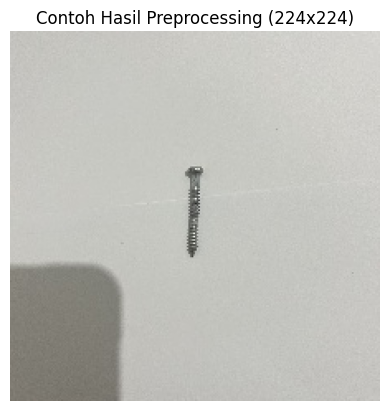

In [5]:
print("=== MEMULAI AUDIT DATA ===")
# Mengambil sampel otomatis dari folder tujuan
files_fix = [f for f in os.listdir(folder_tujuan) if f.endswith(('.jpg', '.jpeg', '.png'))]

if len(files_fix) > 0:
    nama_sampel = files_fix[0]
    img_cek = cv2.imread(os.path.join(folder_tujuan, nama_sampel))
    
    if img_cek is not None:
        img_norm = img_cek.astype('float32') / 255.0
        print(f"Audit Berhasil pada file: {nama_sampel}") 
        print(f"Ukuran Piksel: {img_cek.shape[1]} x {img_cek.shape[0]}")
        print(f"Nilai Maksimum: {np.max(img_norm):.4f}")
        
        # Tampilkan visualisasi langsung di notebook
        plt.imshow(cv2.cvtColor(img_cek, cv2.COLOR_BGR2RGB))
        plt.title("Contoh Hasil Preprocessing (224x224)")
        plt.axis('off')
        plt.show()